# jiu-jitsu-auto-scoring
*This notebook is a **WIP**!*


In [1]:
# prompt: mount drive and clone the repository in the current branch, the organization is called jiu-jitsu-auto-scoring and the repository is called model
from google.colab import drive

BRANCH = "8-fine-tune-vitpose-on-harmony4d" # Write the name of the branch you're working in here

!git clone -q https://github.com/jiu-jitsu-auto-scoring/model.git
%cd /content/model
!git pull
!git checkout $BRANCH

fatal: destination path 'model' already exists and is not an empty directory.
/content/model
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 1.52 KiB | 1.52 MiB/s, done.
From https://github.com/jiu-jitsu-auto-scoring/model
   2ea85f4..596040f  8-fine-tune-vitpose-on-harmony4d -> origin/8-fine-tune-vitpose-on-harmony4d
Updating 2ea85f4..596040f
Fast-forward
 src/Fine_Tune_VitPose_Harmony4d.ipynb | 99 +++++++++++++++++++++++++++++++++++++++++++++++++++++--
 1 file changed, 97 insertions(+), 2 deletions(-)
Already on '8-fine-tune-vitpose-on-harmony4d'
Your branch is up to date with 'origin/8-fine-tune-vitpose-on-harmony4d'.


#0. Imports, Requirements, etc.
Upload the required checkpoint into that folder

In [3]:
# Import drive for custom images
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Install dependencies

In [5]:
# Step 0: Uninstall existing torch-related packages to avoid conflicts
!pip uninstall -y torch torchvision torchaudio

# Step 1: Install basic Python packages (datasets, transformers, etc.)
!pip install datasets transformers huggingface_hub wandb matplotlib scikit-learn opencv-python

# Step 2: Install a complete compatible PyTorch stack with CUDA support
!pip install torch==2.0.1 torchvision==0.15.2 torchaudio==2.0.2 --index-url https://download.pytorch.org/whl/cu118

# Step 3: Install OpenMIM (OpenMMLab package manager)
!pip install -U openmim

# Step 4: Install MMEngine with a specific version known to work with PyTorch 2.0.1
!pip install mmengine==0.7.4

# Step 5: Install MMCV using the exact pre-built wheel for PyTorch 2.0.1
!pip install mmcv==2.0.1 -f https://download.openmmlab.com/mmcv/dist/cu118/torch2.0.0/index.html

# Step 6: Install MMPose with a compatible version
!pip install mmpose==1.1.0

# Step 7: Install any additional dependencies that might be needed
!pip install xtcocotools

Found existing installation: torch 2.0.1
Uninstalling torch-2.0.1:
  Successfully uninstalled torch-2.0.1
Found existing installation: torchvision 0.15.2
Uninstalling torchvision-0.15.2:
  Successfully uninstalled torchvision-0.15.2
Found existing installation: torchaudio 2.6.0+cu124
Uninstalling torchaudio-2.6.0+cu124:
  Successfully uninstalled torchaudio-2.6.0+cu124
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 GB 673.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 92.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.3/374.3 kB 24.2 MB/s eta 0:00:00
  Attempting uninstall: mmengine
    Found existing installation: mmengine 0.10.7
    Uninstalling mmengine-0.10.7:
      Successfully uninstalled mmengine-0.10.7
Looking in links: https://download.openmmlab.com/mmcv/dist/cu118/torch2.0.0/index.html


Choose the datasets you wanna download from Harmony4d: https://huggingface.co/datasets/Jyun-Ting/Harmony4D/tree/main/train

TODO: Verify output images are correct

Exploring dataset structure in: harmony4d_data
harmony4d_data/
    01_hugging/
        001_hugging/
            colmap/
                workplace/
                    ... (7 files)
            processed_data/
                poses3d/
                    ... (301 files)
                bbox/
                    cam05/
                        ... (301 files)
                    cam13/
                        ... (301 files)
                    cam10/
                        ... (301 files)
                    cam14/
                        ... (301 files)
                    cam03/
                        ... (301 files)
                    aria01/
                        rgb/
                            ... (301 files)
                        right/
                            ... (301 files)
                        left/
                            ... (301 files)
                    cam19/
                        ... (301 files)
                    cam08/
                        ... (

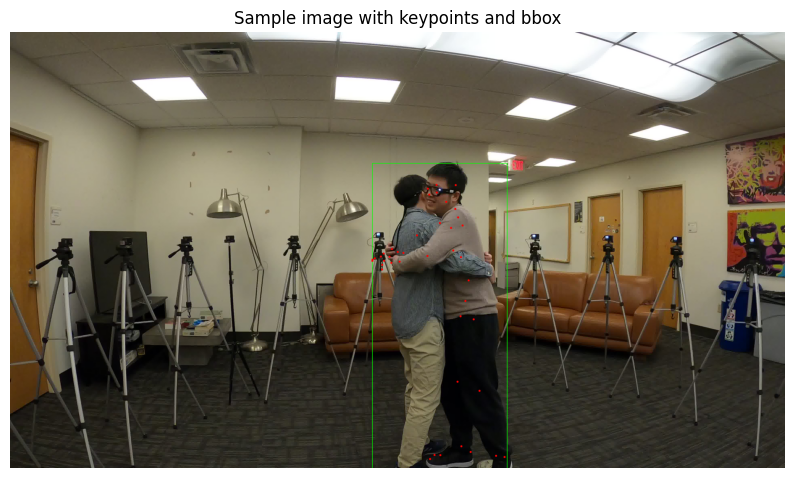

Preparing Harmony4D dataset for ViTPose training...
Found 6622 total images
Total samples collected: 2000


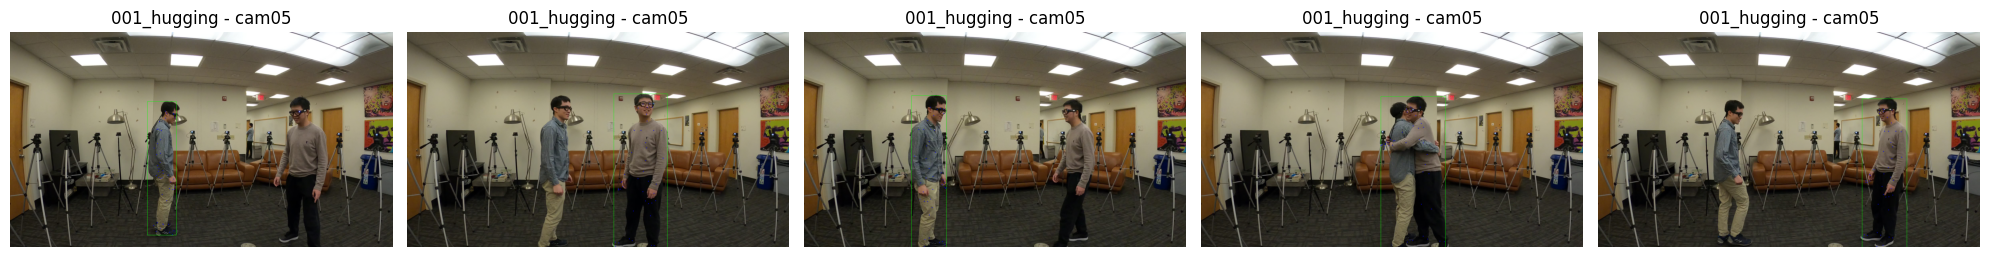

COCO format data saved to vitpose_data/harmony4d_train.json
Total images: 960
Total annotations: 1600
COCO format data saved to vitpose_data/harmony4d_val.json
Total images: 360
Total annotations: 400
Training samples: 1600
Validation samples: 400


In [7]:
# Explore Harmony4D dataset structure
import os
import glob
import numpy as np
import json
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Check the extracted directory structure
data_dir = "harmony4d_data"

def explore_dataset_structure(base_dir):
    """Print the directory structure to understand what we're working with"""
    print("Exploring dataset structure in:", base_dir)

    # Find all subdirectories
    for root, dirs, files in os.walk(base_dir):
        level = root.replace(base_dir, '').count(os.sep)
        indent = ' ' * 4 * level
        print(f"{indent}{os.path.basename(root)}/")

        # Only print files at deepest levels to avoid clutter
        if level >= 3 and files:
            sub_indent = ' ' * 4 * (level + 1)
            file_count = len(files)
            if file_count <= 5:
                for f in files:
                    print(f"{sub_indent}{f}")
            else:
                print(f"{sub_indent}... ({file_count} files)")

# Explore the directory structure
explore_dataset_structure(data_dir)

# Check for poses2d and bbox data
def find_poses_and_bbox(base_dir):
    """Find the keypoint and bbox data in the dataset"""
    image_paths = []
    pose_paths = []
    bbox_paths = []

    # Find image files
    image_files = glob.glob(f"{base_dir}/**/images/*.jpg", recursive=True)
    if image_files:
        image_paths = image_files[:5]  # Just show first 5
        print(f"Found {len(image_files)} image files. Examples:")
        for path in image_paths:
            print(f"  {path}")
    else:
        print("No image files found!")

    # Find pose files
    pose_files = glob.glob(f"{base_dir}/**/poses2d/**/*.npy", recursive=True)
    if pose_files:
        pose_paths = pose_files[:5]  # Just show first 5
        print(f"\nFound {len(pose_files)} pose files. Examples:")
        for path in pose_paths:
            print(f"  {path}")
    else:
        print("\nNo pose files found!")

    # Find bbox files
    bbox_files = glob.glob(f"{base_dir}/**/bbox/**/*.npy", recursive=True)
    if bbox_files:
        bbox_paths = bbox_files[:5]  # Just show first 5
        print(f"\nFound {len(bbox_files)} bbox files. Examples:")
        for path in bbox_paths:
            print(f"  {path}")
    else:
        print("\nNo bbox files found!")

    # If we have all three types, try to examine their content
    if image_paths and pose_paths and bbox_paths:
        print("\nExamining sample data:")
        # Try to find a matching set
        for img_path in image_paths:
            img_dir = os.path.dirname(img_path)
            img_name = os.path.basename(img_path).split('.')[0]
            camera_name = os.path.basename(os.path.dirname(os.path.dirname(img_path)))

            # Try to find corresponding pose and bbox files
            possible_pose_path = glob.glob(f"{base_dir}/**/poses2d/{camera_name}/{img_name}.npy", recursive=True)
            possible_bbox_path = glob.glob(f"{base_dir}/**/bbox/{camera_name}/{img_name}.npy", recursive=True)

            if possible_pose_path and possible_bbox_path:
                pose_path = possible_pose_path[0]
                bbox_path = possible_bbox_path[0]

                print(f"\nImage: {img_path}")
                print(f"Pose: {pose_path}")
                print(f"Bbox: {bbox_path}")

                # Load data
                try:
                    img = cv2.imread(img_path)
                    pose_data = np.load(pose_path, allow_pickle=True)
                    bbox_data = np.load(bbox_path, allow_pickle=True)

                    # Check if these are 0-D arrays
                    if pose_data.ndim == 0:
                        pose_data = pose_data.item()
                    if bbox_data.ndim == 0:
                        bbox_data = bbox_data.item()

                    print(f"Image shape: {img.shape}")
                    print(f"Pose data type: {type(pose_data)}")
                    print(f"Pose data keys: {list(pose_data.keys()) if isinstance(pose_data, dict) else 'Not a dict'}")
                    print(f"Bbox data type: {type(bbox_data)}")
                    print(f"Bbox data keys: {list(bbox_data.keys()) if isinstance(bbox_data, dict) else 'Not a dict'}")

                    # Visualize
                    plt.figure(figsize=(10, 10))
                    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                    # Plot first person's data if available
                    if isinstance(pose_data, dict) and isinstance(bbox_data, dict):
                        person_id = list(pose_data.keys())[0] if pose_data else None
                        if person_id and person_id in bbox_data:
                            # Draw bbox
                            bbox = bbox_data[person_id]
                            x_min, y_min, x_max, y_max = bbox
                            cv2.rectangle(img_rgb, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 255, 0), 2)

                            # Draw keypoints
                            keypoints = pose_data[person_id]
                            for kp in keypoints:
                                if len(kp) >= 2:
                                    x, y = int(kp[0]), int(kp[1])
                                    cv2.circle(img_rgb, (x, y), 5, (255, 0, 0), -1)

                    plt.imshow(img_rgb)
                    plt.title("Sample image with keypoints and bbox")
                    plt.axis('off')
                    plt.show()

                    # Stop after finding one matching set
                    break
                except Exception as e:
                    print(f"Error examining data: {e}")


    return image_files, pose_files, bbox_files

# Find the relevant files
image_files, pose_files, bbox_files = find_poses_and_bbox(data_dir)

# Create an improved version of the data preparation function
def prepare_harmony4d_for_vitpose_improved(base_dir=data_dir):
    """
    Revised function to collect and prepare Harmony4D data for ViTPose training
    """
    print("Preparing Harmony4D dataset for ViTPose training...")
    all_data = []

    # First, find all image files
    image_files = glob.glob(f"{base_dir}/**/images/*.jpg", recursive=True)
    print(f"Found {len(image_files)} total images")

    # Process each image file
    for image_path in image_files[:1000]:  # Limit to 1000 images for initial testing
        try:
            # Extract directory components
            img_name = os.path.basename(image_path).split('.')[0]
            img_dir = os.path.dirname(image_path)
            camera_dir = os.path.dirname(img_dir)
            camera_name = os.path.basename(camera_dir)

            # Find parent folders containing "processed_data"
            activity_dir = None
            curr_dir = os.path.dirname(camera_dir)
            while curr_dir != base_dir and curr_dir != '/':
                if os.path.exists(os.path.join(curr_dir, "processed_data")):
                    activity_dir = curr_dir
                    break
                curr_dir = os.path.dirname(curr_dir)

            if not activity_dir:
                continue

            activity_name = os.path.basename(activity_dir)

            # Construct paths to pose and bbox files
            poses2d_dir = os.path.join(activity_dir, "processed_data", "poses2d", camera_name)
            bbox_dir = os.path.join(activity_dir, "processed_data", "bbox", camera_name)

            poses2d_path = os.path.join(poses2d_dir, f"{img_name}.npy")
            bbox_path = os.path.join(bbox_dir, f"{img_name}.npy")

            if not os.path.exists(poses2d_path) or not os.path.exists(bbox_path):
                continue

            # Load data
            poses2d_data = np.load(poses2d_path, allow_pickle=True)
            bbox_data = np.load(bbox_path, allow_pickle=True)

            # Handle 0-D arrays
            if poses2d_data.ndim == 0:
                poses2d_data = poses2d_data.item()
            if bbox_data.ndim == 0:
                bbox_data = bbox_data.item()

            # Make sure both are dictionaries
            if not isinstance(poses2d_data, dict) or not isinstance(bbox_data, dict):
                continue

            # Process each person in the image
            for person_id in poses2d_data.keys():
                if person_id in bbox_data:
                    keypoints = poses2d_data[person_id]
                    bbox = bbox_data[person_id]

                    # Skip bad data
                    if not isinstance(keypoints, (list, np.ndarray)) or not isinstance(bbox, (list, np.ndarray)):
                        continue

                    # Make sure we have valid keypoints
                    if len(keypoints) < 1:
                        continue

                    # Store the data
                    data_item = {
                        "image_path": image_path,
                        "person_id": person_id,
                        "keypoints": keypoints,
                        "bbox": bbox,
                        "activity": activity_name,
                        "camera": camera_name
                    }
                    all_data.append(data_item)
        except Exception as e:
            # Just skip problematic files
            continue

    print(f"Total samples collected: {len(all_data)}")
    return all_data

# Try the improved data preparation
harmony4d_data = prepare_harmony4d_for_vitpose_improved()

# Visualize samples if we have data
def visualize_samples(data, num_samples=5):
    """
    Visualize random samples to verify keypoints and bounding boxes
    """
    if not data:
        print("No data available for visualization")
        return

    # Select random samples
    import random
    sample_indices = random.sample(range(len(data)), min(num_samples, len(data)))
    samples = [data[i] for i in sample_indices]

    # Create figure
    fig, axes = plt.subplots(1, len(samples), figsize=(20, 5))
    if len(samples) == 1:
        axes = [axes]

    for i, sample in enumerate(samples):
        # Load image
        img = cv2.imread(sample["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Draw bounding box
        x_min, y_min, x_max, y_max = sample["bbox"]
        cv2.rectangle(img, (int(x_min), int(y_min)), (int(x_max), int(y_max)), (0, 255, 0), 2)

        # Draw keypoints
        colors = [(255, 0, 0), (0, 0, 255), (255, 255, 0)]
        for kp_idx, kp in enumerate(sample["keypoints"]):
            if len(kp) >= 2:
                x, y = kp[0], kp[1]
                v = kp[2] if len(kp) > 2 else 2
                if v > 0:  # Only draw visible keypoints
                    color_idx = min(int(v) - 1, len(colors) - 1) if int(v) > 0 else 0
                    cv2.circle(img, (int(x), int(y)), 4, colors[color_idx], -1)

        # Display
        axes[i].imshow(img)
        axes[i].set_title(f"{sample['activity']} - {sample['camera']}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Visualize if we found data
if harmony4d_data:
    visualize_samples(harmony4d_data)

    # Split data (80% train, 20% val)
    random.shuffle(harmony4d_data)
    split_idx = int(len(harmony4d_data) * 0.8)
    train_data = harmony4d_data[:split_idx]
    val_data = harmony4d_data[split_idx:]

    output_dir = "vitpose_data"
    os.makedirs(output_dir, exist_ok=True)

    # Convert to COCO format
    train_json = os.path.join(output_dir, "harmony4d_train.json")
    val_json = os.path.join(output_dir, "harmony4d_val.json")

    def convert_to_coco_format(data, output_path, img_prefix):
        """
        Convert the collected data to COCO format for ViTPose training
        """
        coco_data = {
            "images": [],
            "annotations": [],
            "categories": [{
                "id": 1,
                "name": "person",
                "supercategory": "person",
                "keypoints": [
                    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
                    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
                    "left_wrist", "right_wrist", "left_hip", "right_hip",
                    "left_knee", "right_knee", "left_ankle", "right_ankle"
                ],
                "skeleton": [
                    [16, 14], [14, 12], [17, 15], [15, 13], [12, 13], [6, 12],
                    [7, 13], [6, 7], [6, 8], [7, 9], [8, 10], [9, 11], [2, 3],
                    [1, 2], [1, 3], [2, 4], [3, 5], [4, 6], [5, 7]
                ]
            }]
        }

        image_id_map = {}
        annotation_id = 1

        for idx, item in enumerate(data):
            image_path = item["image_path"]

            # Get or create image ID
            if image_path not in image_id_map:
                # Get image dimensions
                img = cv2.imread(image_path)
                height, width = img.shape[:2]

                image_id = len(image_id_map) + 1
                image_id_map[image_path] = image_id

                # Create relative path
                file_name = os.path.relpath(image_path, img_prefix)

                # Add image info
                coco_data["images"].append({
                    "id": image_id,
                    "file_name": file_name,
                    "width": width,
                    "height": height
                })
            else:
                image_id = image_id_map[image_path]

            # Format keypoints for COCO
            keypoints = item["keypoints"]
            # COCO format requires flattened [x1, y1, v1, x2, y2, v2, ...] format
            flattened_keypoints = []
            for kp in keypoints:
                if len(kp) >= 2:  # [x, y] or [x, y, visibility]
                    x, y = kp[0], kp[1]
                    v = kp[2] if len(kp) > 2 else 2  # Default to visible if not specified
                    flattened_keypoints.extend([float(x), float(y), int(v)])

            # Make sure we have 17 keypoints (required for COCO format)
            if len(flattened_keypoints) < 51:  # 17 keypoints * 3 values
                # Pad with zeros for missing keypoints
                flattened_keypoints.extend([0, 0, 0] * (17 - len(flattened_keypoints) // 3))

            # Format bbox (COCO uses [x, y, width, height])
            x_min, y_min, x_max, y_max = item["bbox"]
            width = x_max - x_min
            height = y_max - y_min
            coco_bbox = [float(x_min), float(y_min), float(width), float(height)]

            # Add annotation
            coco_data["annotations"].append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": 1,
                "bbox": coco_bbox,
                "area": float(width * height),
                "segmentation": [],
                "iscrowd": 0,
                "keypoints": flattened_keypoints,
                "num_keypoints": len(keypoints)
            })

            annotation_id += 1

        # Save to JSON file
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        with open(output_path, "w") as f:
            json.dump(coco_data, f)

        print(f"COCO format data saved to {output_path}")
        print(f"Total images: {len(coco_data['images'])}")
        print(f"Total annotations: {len(coco_data['annotations'])}")

        return coco_data

    train_coco = convert_to_coco_format(train_data, train_json, data_dir)
    val_coco = convert_to_coco_format(val_data, val_json, data_dir)

    print(f"Training samples: {len(train_data)}")
    print(f"Validation samples: {len(val_data)}")

Set up ViTPose configuration and start the training:

In [16]:
!pip install -U yapf # We needed this to fix a dependency issue?

In [27]:
# Script to convert our existing Harmony4D JSONs to COCO standard 17 keypoints
import os
import json

# Define paths
output_dir = os.path.abspath("vitpose_data")
train_json = os.path.join(output_dir, "harmony4d_train.json")
val_json = os.path.join(output_dir, "harmony4d_val.json")
train_json_17kpt = os.path.join(output_dir, "harmony4d_train_17kpt.json")
val_json_17kpt = os.path.join(output_dir, "harmony4d_val_17kpt.json")

def convert_to_17kpt(input_json, output_json): # TODO: put this in data processing block
    """Convert JSON with many keypoints to standard COCO format with 17 keypoints"""
    print(f"Converting {input_json} to 17-keypoint format...")

    # Load the original JSON
    with open(input_json, 'r') as f:
        data = json.load(f)

    # Make a copy
    new_data = {
        "images": data["images"],
        "categories": data["categories"],
        "annotations": []
    }

    # Process each annotation
    for ann in data["annotations"]:
        # Extract original keypoints array
        orig_keypoints = ann["keypoints"]

        # Take only the first 17 keypoints (3 values each: x, y, v)
        new_keypoints = orig_keypoints[:51]  # 17 keypoints * 3 values

        # Pad if necessary
        if len(new_keypoints) < 51:
            new_keypoints.extend([0, 0, 0] * (17 - len(new_keypoints) // 3))

        # Create new annotation with 17 keypoints
        new_ann = ann.copy()
        new_ann["keypoints"] = new_keypoints
        new_ann["num_keypoints"] = min(ann.get("num_keypoints", 17), 17)

        new_data["annotations"].append(new_ann)

    # Save the new JSON
    with open(output_json, 'w') as f:
        json.dump(new_data, f)

    print(f"Converted data saved to {output_json}")
    print(f"Original annotations: {len(data['annotations'])}")
    print(f"Converted annotations: {len(new_data['annotations'])}")
    return output_json

# Convert the train and validation JSONs
train_json_17kpt = convert_to_17kpt(train_json, train_json_17kpt)
val_json_17kpt = convert_to_17kpt(val_json, val_json_17kpt)

# Update the configuration to use the 17-keypoint JSONs
config_file = os.path.join(os.getcwd(), "vitpose_harmony4d_config.py")
work_dir = os.path.join(os.getcwd(), "work_dirs/vitpose_harmony4d")
data_root = os.path.abspath("harmony4d_data")

config_content = f"""
_base_ = ['/usr/local/lib/python3.11/dist-packages/mmpose/.mim/configs/body_2d_keypoint/topdown_regression/coco/td-reg_res50_rle-pretrained-8xb64-210e_coco-256x192.py']

# Minimal modifications - just update the dataset paths to use 17kpt files
train_dataloader = dict(
    dataset=dict(
        data_root='{data_root}',
        ann_file='{train_json_17kpt}',
        data_prefix=dict(img=''),
    )
)

val_dataloader = dict(
    dataset=dict(
        data_root='{data_root}',
        ann_file='{val_json_17kpt}',
        data_prefix=dict(img=''),
        bbox_file=None,
        test_mode=True,
    )
)

test_dataloader = dict(
    dataset=dict(
        data_root='{data_root}',
        ann_file='{val_json_17kpt}',
        data_prefix=dict(img=''),
        bbox_file=None,
        test_mode=True,
    )
)

# Update evaluator to use our 17-keypoint annotation file
val_evaluator = dict(ann_file='{val_json_17kpt}')
test_evaluator = dict(ann_file='{val_json_17kpt}')

# Modify training schedule
train_cfg = dict(
    max_epochs=20,
    val_interval=5
)

# Set the work directory
work_dir = '{work_dir}'
"""

# Write configuration to file
with open(config_file, "w") as f:
    f.write(config_content)

print(f"Updated configuration file created: {config_file}")

# Run the training with the updated config
!python /usr/local/lib/python3.11/dist-packages/mmpose/.mim/tools/train.py {config_file} --work-dir {work_dir}

Converting /content/vitpose_data/harmony4d_train.json to 17-keypoint format...
Converted data saved to /content/vitpose_data/harmony4d_train_17kpt.json
Original annotations: 1600
Converted annotations: 1600
Converting /content/vitpose_data/harmony4d_val.json to 17-keypoint format...
Converted data saved to /content/vitpose_data/harmony4d_val_17kpt.json
Original annotations: 400
Converted annotations: 400
Updated configuration file created: /content/vitpose_harmony4d_config.py
03/16 16:29:52 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.11.11 (main, Dec  4 2024, 08:55:07) [GCC 11.4.0]
    CUDA available: True
    numpy_random_seed: 269156795
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.5, V12.5.82
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04) 11.4.0
    PyTorch: 2.0.1+cu118
    PyTorch compiling details: PyTorch built with:
  - G

In [30]:
!pip install huggingface_hub
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: write).
The token `new detr token` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `new detr 

In [32]:
from huggingface_hub import HfApi
import os

def upload_to_huggingface(
    local_folder,
    repo_name='harmony4d-vitpose-model',
    repo_owner='your_username',
    commit_message='Upload Harmony4D VitPose model and configuration'
):
    """
    Upload model checkpoints and configuration to Hugging Face
    """
    # Initialize API
    api = HfApi()

    # Create repository if it doesn't exist
    try:
        api.create_repo(
            repo_id=f"{repo_owner}/{repo_name}",
            repo_type="model",
            exist_ok=True
        )
    except Exception as e:
        print(f"Error creating repository: {e}")
        return

    # Files to upload
    files_to_upload = [
        'best_coco_AP_epoch_20.pth',  # Best model checkpoint
        'vitpose_harmony4d_config.py',  # Configuration file
        'last_checkpoint',  # Last checkpoint pointer
        'epoch_20.pth',  # Final epoch checkpoint
    ]

    # Full file paths
    file_paths = [os.path.join(local_folder, f) for f in files_to_upload]

    # Upload files
    try:
        for file_path in file_paths:
            if os.path.exists(file_path):
                api.upload_file(
                    path_or_fileobj=file_path,
                    path_in_repo=os.path.basename(file_path),
                    repo_id=f"{repo_owner}/{repo_name}",
                    commit_message=commit_message
                )
                print(f"Uploaded {file_path}")
            else:
                print(f"File not found: {file_path}")

    except Exception as e:
        print(f"Error uploading files: {e}")

# Prompt for username
import getpass
repo_owner = input("Enter your Hugging Face username: ")
local_folder = '/content/work_dirs/vitpose_harmony4d'

# Upload
upload_to_huggingface(
    local_folder=local_folder,
    repo_owner=repo_owner
)

# Optional: Create model card
def create_model_card(repo_name, repo_owner):
    """Create a README.md model card for the Hugging Face repository"""
    model_card = """# Harmony4D VitPose Model

## Model Details
- **Task**: Human Pose Estimation
- **Dataset**: Harmony4D
- **Backbone**: ResNet50
- **Best Performance**:
  - Average Precision (AP): 0.6485
  - AP @ IoU=0.50: 0.9357
  - AP @ IoU=0.75: 0.7681

## Training Details
- Total Epochs: 20
- Learning Rate: Adaptive (starting from 0.001)
- Optimization: Adam

## Usage
```python
from mmpose.apis import inference_bottom_up_pose_model
from mmpose.utils import register_all_modules

# Load the model
config_file = 'vitpose_harmony4d_config.py'
checkpoint_file = 'best_coco_AP_epoch_20.pth'
model = inference_bottom_up_pose_model(config_file, checkpoint_file)
```

## Limitations
- Trained on Harmony4D dataset
- Performance may vary on different datasets
"""

    # Upload model card
    api = HfApi()
    api.upload_file(
        path_or_fileobj=model_card,
        path_in_repo='README.md',
        repo_id=f"{repo_owner}/{repo_name}",
        commit_message='Add model card'
    )

print("Hugging Face upload script ready!")

Enter your Hugging Face username: Krusher99


best_coco_AP_epoch_20.pth:   0%|          | 0.00/95.2M [00:00<?, ?B/s]

Uploaded /content/work_dirs/vitpose_harmony4d/best_coco_AP_epoch_20.pth
Uploaded /content/work_dirs/vitpose_harmony4d/vitpose_harmony4d_config.py
Uploaded /content/work_dirs/vitpose_harmony4d/last_checkpoint


epoch_20.pth:   0%|          | 0.00/285M [00:00<?, ?B/s]

Uploaded /content/work_dirs/vitpose_harmony4d/epoch_20.pth
Hugging Face upload script ready!
